<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Exercice_XP_J2_W2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Chargement du dataset

import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
#Exercice 1 : Détection et suppression des doublons

#Nombre de lignes avant
print("Rows before:", df.shape[0])

#Détection des doublons
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

#Suppression des doubles lignes
df = df.drop_duplicates()

#Vérification
print("Rows after:", df.shape[0])

Rows before: 891
Number of duplicate rows: 0
Rows after: 891


In [3]:
#Exercice 2 : Gestion des valeurs manquantes

#Identifier les colonnes concernées
df.isnull().sum()

#Stratégie 1 : Supprimer une colonne très vide
df.drop(columns=['Cabin'], inplace=True)

#Stratégie 2 : Imputer l'âge par la médiane
df['Age'] = df['Age'].fillna(
    df['Age'].median()
)

#Stratégie 3: Embarked par la valeur la plus fréquente
df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

#Vérification
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
#Exercice 3 : Feature Engineering

#Family size
df['FamilySize'] = (
    df['SibSp']
    + df['Parch']
    + 1
)

#Extraire le titre
# Mr.
# Mrs.
# Miss.
# Master.
df['Title'] = (
    df['Name']
    .str.extract(r' ([A-Za-z]+)\.', expand=False)
)

#Vérification
df['Title'].value_counts()

#Encoder Title
df = pd.get_dummies(
    df,
    columns=['Title'],
    drop_first=True
)


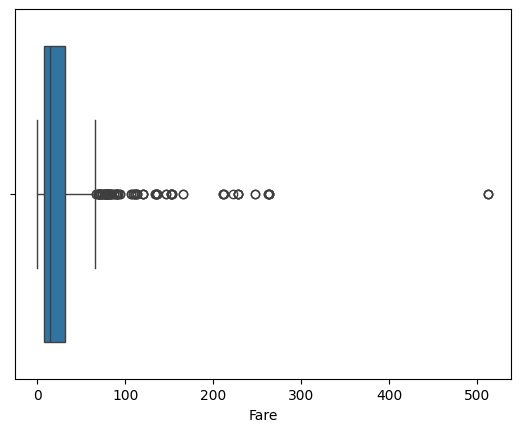

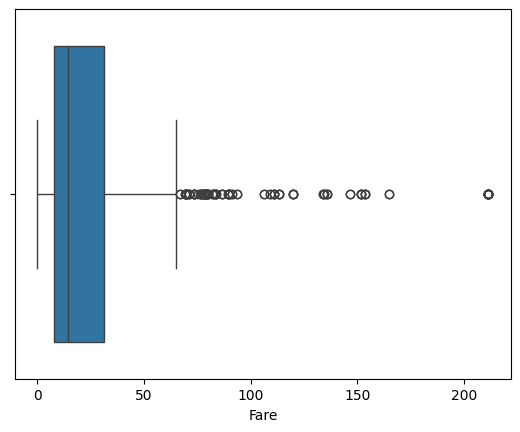

In [8]:
#Exercice 4 : Détection et traitement des outliers

#Boxplot Fare
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Fare'])

plt.show()

#Détection IQR
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

#Quantile Capping à 98%
upper_cap = df['Fare'].quantile(0.98)

df['Fare'] = np.where(
    df['Fare'] > upper_cap,
    upper_cap,
    df['Fare']
)

#Vérification
sns.boxplot(x=df['Fare'])

plt.show()

In [9]:
#Exercice 5 : Standardisation et normalisation

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler
)

#StandardScaler pour Age
scaler = StandardScaler()

df['Age_scaled'] = scaler.fit_transform(
    df[['Age']]
)

#MinMax pour Fare
minmax = MinMaxScaler()

df['Fare_scaled'] = minmax.fit_transform(
    df[['Fare']]
)


In [10]:
#Exercice 6 : Encodage final

#Identifier les colonnes catégorielles restantes :
df.select_dtypes(
    include='object'
).columns

#One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=[
        'Sex',
        'Embarked'
    ],
    drop_first=True
)


In [11]:
#Exercice 7 : Transformation de Age

#Création des groupes
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,12,18,60,100],
    labels=[
        'Child',
        'Teen',
        'Adult',
        'Senior'
    ]
)
#Vérification
df['AgeGroup'].value_counts()

#One-Hot Encoding
age_dummies = pd.get_dummies(
    df['AgeGroup'],
    prefix='Age'
)

df = pd.concat(
    [df, age_dummies],
    axis=1
)

#Dataset final
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,FamilySize,...,Age_scaled,Fare_scaled,Sex_male,Embarked_Q,Embarked_S,AgeGroup,Age_Child,Age_Teen,Age_Adult,Age_Senior
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,2,...,-0.565736,0.034305,True,False,True,Adult,False,False,True,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,2,...,0.663861,0.337296,False,False,False,Adult,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,...,-0.258337,0.037499,False,False,True,Adult,False,False,True,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,2,...,0.433312,0.251257,False,False,True,Adult,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,...,0.433312,0.038091,True,False,True,Adult,False,False,True,False
